In [1]:
import numpy as np
from scipy.ndimage import label, binary_fill_holes


tt = np.load('./case2rho.npy')
tt_clean = np.load('./case2rho_clean.npy')

In [2]:
import numpy as np
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve


def calc_compliance(xPhys, penal=3):
    """
    计算给定密度矩阵的 compliance。

    Parameters
    ----------
    xPhys : np.ndarray, shape (nely, nelx)
        密度矩阵，值域 [0, 1]。
    penal : float
        惩罚指数，默认 3。

    Returns
    -------
    c : float
        结构柔度（compliance）。
    """
    nely, nelx = xPhys.shape

    # ------------------------------------------------------------------ #
    #  MATERIAL PROPERTIES
    # ------------------------------------------------------------------ #
    E0   = 1000.0
    Emin = 1e-9
    nu   = 0.3

    # ------------------------------------------------------------------ #
    #  ELEMENT STIFFNESS MATRIX
    # ------------------------------------------------------------------ #
    A11 = np.array([[ 12,  3, -6, -3],
                    [  3, 12,  3,  0],
                    [ -6,  3, 12, -3],
                    [ -3,  0, -3, 12]])
    A12 = np.array([[ -6, -3,  0,  3],
                    [ -3, -6, -3, -6],
                    [  0, -3, -6,  3],
                    [  3, -6,  3, -6]])
    B11 = np.array([[ -4,  3, -2,  9],
                    [  3, -4, -9,  4],
                    [ -2, -9, -4, -3],
                    [  9,  4, -3, -4]])
    B12 = np.array([[  2, -3,  4, -9],
                    [ -3,  2,  9, -2],
                    [  4,  9,  2,  3],
                    [ -9, -2,  3,  2]])
    KE = (1 / (1 - nu**2) / 24) * (
        np.block([[A11, A12], [A12.T, A11]])
        + nu * np.block([[B11, B12], [B12.T, B11]])
    )

    # ------------------------------------------------------------------ #
    #  DOF MAP
    # ------------------------------------------------------------------ #
    ndof    = 2 * (nelx + 1) * (nely + 1)
    nodenrs = np.arange(1, (1+nelx)*(1+nely)+1).reshape(1+nely, 1+nelx, order='F')
    edofVec = (2 * nodenrs[:nely, :nelx] + 1).reshape(nelx*nely, 1, order='F')
    offsets = np.array([0, 1, 2*nely+2, 2*nely+3, 2*nely, 2*nely+1, -2, -1])
    edofMat = (np.tile(edofVec, (1, 8)) + np.tile(offsets, (nelx*nely, 1)) - 1).astype(int)

    iK = np.tile(edofMat, 8).flatten().astype(int)
    jK = np.repeat(edofMat, 8, axis=1).flatten().astype(int)

    # ------------------------------------------------------------------ #
    #  LOADS AND SUPPORTS
    #  右上角节点施加向下集中力，左边全固定
    # ------------------------------------------------------------------ #
    F = np.zeros(ndof)
    F[2 * (nelx * (nely + 1) + nely) + 1] = -0.1

    fixeddofs = np.arange(0, 2 * (nely + 1))
    freedofs  = np.setdiff1d(np.arange(ndof), fixeddofs)

    # ------------------------------------------------------------------ #
    #  ASSEMBLE & SOLVE
    # ------------------------------------------------------------------ #
    elem_mods = Emin + xPhys.flatten(order='F')**penal * (E0 - Emin)
    sK = (KE.flatten(order='F')[:, None] * elem_mods[None, :]).flatten(order='F')
    K  = sp.csr_matrix((sK, (iK, jK)), shape=(ndof, ndof))
    K  = (K + K.T) / 2

    U = np.zeros(ndof)
    U[freedofs] = spsolve(K[freedofs, :][:, freedofs], F[freedofs])

    # ------------------------------------------------------------------ #
    #  COMPLIANCE
    # ------------------------------------------------------------------ #
    Ue = U[edofMat]
    ce = (Ue @ KE * Ue).sum(axis=1).reshape(nely, nelx, order='F')
    c  = np.sum((Emin + xPhys**penal * (E0 - Emin)) * ce)

    return c

In [3]:
calc_compliance(tt_clean)

0.030117686292509514

In [4]:
calc_compliance(tt)

0.006801621988968636

(-0.5, 119.5, 39.5, -0.5)

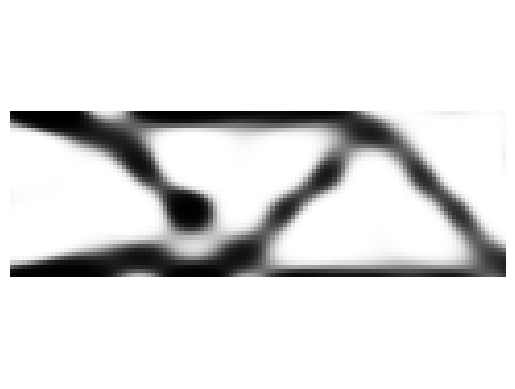

In [5]:
import matplotlib.pyplot as plt
fig = plt.figure()
plt.imshow(-tt, cmap='gray')
plt.axis('equal')
plt.axis('off')


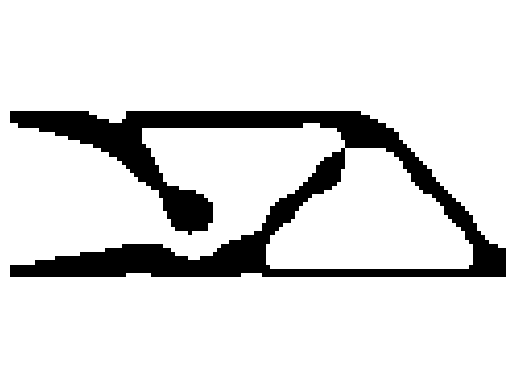

In [6]:
import matplotlib.pyplot as plt
fig = plt.figure()
plt.imshow(1-tt_clean, cmap='gray')
plt.axis('equal')
plt.axis('off')
plt.savefig("./RFM2Dbeamcenter.pdf",dpi=300)